### Implementation using Gillespie Algorithm

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt

# Parameters
kn, ka, kd, kf, nc = 1e-1, 1e-3, 1e-1, 1e-2, 3  # either dissociation OR fragmentation size should be zero?!
tmax, jmax = 200, 20  # 200, 10

lengths = np.arange(1, jmax + 1)
Mt = lambda f: np.dot(lengths, f[1:])
Pt = lambda f: np.sum(f[1:])

# 0. Set initial conditions
m0, t = 1e3, 0

f = np.zeros(jmax + 1)  # index 0 is unused; polymer lengths run from 1..jmax (or rather nc...jmax)!
ft, tt, Mtt, Ptt = [np.copy(f)], [t], [Mt(f)], [Pt(f)]
assoc_rates, dissoc_rates, fragm_rates = np.zeros_like(f), np.zeros_like(f), np.zeros_like(f)

# run Gillespie
total_rate = 1
while t <= tmax and total_rate > 0:
    # 1. update rates
    mt = m0 - Mt(f)
    nucl_rate = kn * (mt/m0)**nc  # nucleation rate (normalised)
    for j in range(nc + 1, jmax + 1): assoc_rates[j] = ka * mt * f[j - 1]
    for j in range(nc + 2, jmax + 1):
        dissoc_rates[j] = kd * f[j]; fragm_rates[j] = kf * f[j] * (j - 1)
    total_rate = nucl_rate + np.sum(assoc_rates) + np.sum(dissoc_rates) + np.sum(fragm_rates)
    if total_rate <= 0:
        print('total_rate=', total_rate)
        break

    # 2. time to next reaction
    rn1 = random.random()
    tau = -np.log(rn1) / total_rate
    # 3. find which reaction will take place
    rn2 = random.random()
    done = False

    if rn2 < nucl_rate / total_rate:
        f[nc] += 1
        done = True
    else:
        current_rate = nucl_rate
        for jj in range(nc + 1, jmax + 1):  # association
            current_rate += assoc_rates[jj]
            if not done and rn2 < current_rate / total_rate:
                f[jj] += 1; f[jj - 1] -= 1
                done = True
                break
        for jj in range(nc + 2, jmax + 1):  # dissociation
            current_rate += dissoc_rates[jj]
            if not done and rn2 < current_rate / total_rate:
                f[jj] -= 1; f[jj - 1] += 1
                done = True
                break
        for jj in range(nc + 1, jmax + 1):  # fragmentation
            current_rate += fragm_rates[jj]
            if not done and rn2 < current_rate / total_rate:
                f[jj] -= 1
                break_point = random.randint(1, jj - 1)
                if break_point <= nc:  # if the break point is in the nucleation range, we just get monomers
                    f[jj-break_point] += 1
                elif break_point >= jj - nc:
                    f[break_point] += 1
                else:
                    f[jj - break_point] += 1
                    f[break_point] += 1
                done = True
                break

    # 4. advance in time with tau
    t += tau

    # save values for plotting
    ft.append(np.copy(f))
    Mtt.append(Mt(f))
    Ptt.append(Pt(f))
    tt.append(t)

ft, tt, Mtt, Ptt = np.array(ft), np.array(tt), np.array(Mtt), np.array(Ptt)
print(np.shape(ft), f'total_rate={total_rate}', tt[-1], Ptt[-1], Mtt[-1])

(5175, 21) total_rate=34.4782406104 200.0708833058397 174.0 863.0


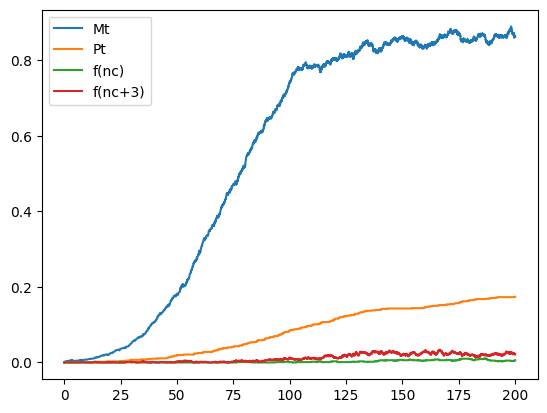

In [11]:
plt.plot(tt, Mtt / m0, label='Mt'); plt.plot(tt, Ptt / m0, label='Pt')  # how does M(t),P(t) look
plt.plot(tt, ft[:,nc]/m0, label='f(nc)'); plt.plot(tt, ft[:,nc+3]/m0, label='f(nc+3)') # how does f(nc) look
plt.legend()

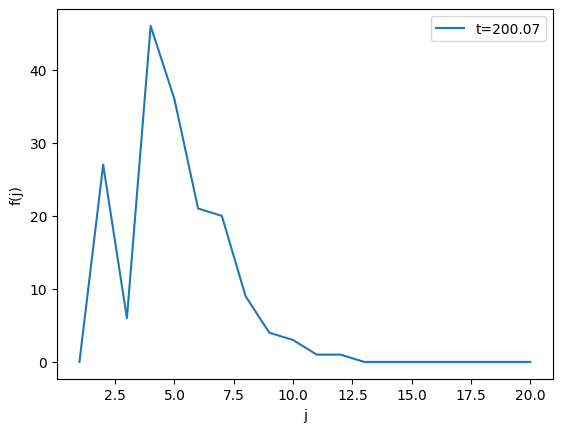

In [12]:
# how does f(t,j) look at a given time point?
t_idx = -1  # index
plt.plot(lengths, ft[t_idx, 1:])
plt.xlabel('j'); plt.ylabel('f(j)')
plt.legend([f't={tt[t_idx]:0.2f}'])

Text(0, 0.5, 'f(j)')

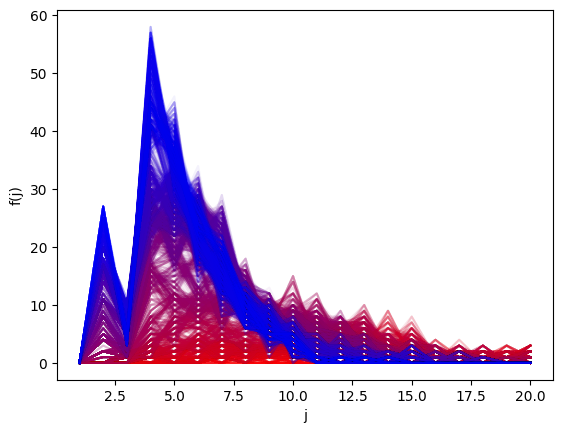

In [13]:
# combining all times
T = len(tt)
for i in range(1, T):
    plt.plot(lengths, ft[i, 1:], color = ((T - i) / T, 0, i / T), alpha=0.05)
plt.xlabel('j')
plt.ylabel('f(j)')
# plt.legend(tt)

### Results
- theoretical results (without dissociation) when mass grows primarily due to association:
$$ P(t) = \frac{2C_1}{n_c}\sqrt{\frac{k_n}{k_a}}\text{tanh}(C_1\sqrt{k_ak_nt}+C_2) \quad M(t) = m_0 - (2C_1^2/n_c)^{1/n_c}[\text{cosh}(C_1\sqrt{k_ak_nt}+C_2)]^{-2/n_c} $$
- so higher $k_a,k_n$ lead to reaching the stationary state faster; higher $k_a,n_c$ and lower $k_n$ lead to lower total number $P(t)$ in the end, final mass is always $m_0$ here! -> these trends are also reflected in the data!
- dissociation term yields steady state at some point (final mass is determined by ration of association and dissociation)!
- adding fragmentation yields similar behaviour but with an initial "kink" (nonlinearity)!